# Pix2Pix MoNuSeg — Inference Demo

This notebook demonstrates inference with the trained Pix2Pix models on paired images from the MoNuSeg test set.

Each paired image contains:
- **Left half**: real H&E-stained histology image.
- **Right half**: corresponding label map (nuclei segmentation).

Our generator takes the label map as input and produces a realistic histology image. We then display the input label, the generated image, and the ground-truth real image side by side.

The notebook reuses the same inference functions as the command-line demo (`demo/demo.py`), so the results are identical.

## 1. Setup

We import the inference utilities from `inference.py`. Make sure you have run `pip install -r requirements.txt` from the project root before executing this notebook.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Robust demo paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

# If the notebook is run from demo/, the repository root is one level above.
# If it is run from the repository root, the repository root is the current folder.
if CURRENT_DIR.name == "demo":
    REPO_ROOT = CURRENT_DIR.parent
    DEMO_DIR = CURRENT_DIR
else:
    REPO_ROOT = CURRENT_DIR
    DEMO_DIR = REPO_ROOT / "demo"

# Optional local checkpoints directory.
# It is only used if USE_LOCAL_CHECKPOINTS = True in the loading cells.
CHECKPOINTS_DIR = REPO_ROOT / "checkpoints"

SAMPLES_DIR = DEMO_DIR / "samples"
OUTPUTS_DIR = DEMO_DIR / "outputs"

# Allow imports from demo/inference.py and root/models.py.
for path in [REPO_ROOT, DEMO_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from inference import (
    AVAILABLE_MODELS,
    HUGGINGFACE_REPO_ID,
    load_generator,
    resolve_checkpoint_path,
    run_inference_on_paired_image,
    make_side_by_side_figure,
)

print(f"Current directory: {CURRENT_DIR}")
print(f"Repository root:   {REPO_ROOT}")
print(f"Demo directory:    {DEMO_DIR}")
print(f"Samples directory: {SAMPLES_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")
print(f"Checkpoints dir:   {CHECKPOINTS_DIR} (optional)")
print(f"Hugging Face repo: {HUGGINGFACE_REPO_ID}")
print(f"Available models:  {list(AVAILABLE_MODELS)}")

if not SAMPLES_DIR.exists():
    raise FileNotFoundError(
        f"Samples directory not found: {SAMPLES_DIR}. "
        "Please make sure demo/samples/ exists."
    )

Current directory: c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\demo
Repository root:   c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo
Demo directory:    c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\demo
Samples directory: c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\demo\samples
Outputs directory: c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\demo\outputs
Checkpoints dir:   c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\checkpoints (optional)
Hugging Face repo: hugogs-7/pix2pix-monuseg
Available models:  ['baseline', 'aug', 'lsgan', 'multi', 'improved']


## 2. Choose a model and an input image

By default we use the **best improved model** (augmentation + LSGAN + multi-scale discriminator), but you can switch to any of the five trained variants by changing `MODEL_NAME` below.

The first time you run a given model, the checkpoint will be downloaded from Hugging Face Hub (~200 MB) and cached locally.

In [2]:
MODEL_NAME = "improved"  # one of: baseline, aug, lsgan, multi, improved

sample_images = sorted(SAMPLES_DIR.glob("*.png"))

if not sample_images:
    raise FileNotFoundError(
        f"No sample images found in {SAMPLES_DIR}. "
        "Please add some MoNuSeg test-set images to demo/samples/."
    )

INPUT_IMAGE = sample_images[0]

print(f"Input image: {INPUT_IMAGE}")
print(f"Model: {MODEL_NAME}")

Input image: c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\demo\samples\image_099.png
Model: improved


## 3. Load the generator

In [3]:
# ------------------------------------------------------------
# Load selected generator
# ------------------------------------------------------------

USE_LOCAL_CHECKPOINTS = False  # Set to True only for local development

if USE_LOCAL_CHECKPOINTS:
    checkpoint_path = resolve_checkpoint_path(
        model_name=MODEL_NAME,
        local_checkpoints_dir=CHECKPOINTS_DIR,
    )
else:
    checkpoint_path = resolve_checkpoint_path(
        model_name=MODEL_NAME,
    )

print(f"Checkpoint: {checkpoint_path}")

generator, device = load_generator(checkpoint_path)
print(f"Device: {device}")

Checkpoint: C:\Users\Hugo\.cache\huggingface\hub\models--hugogs-7--pix2pix-monuseg\snapshots\43df77ab6cff8366034aacb00e89c3daffc03f54\improved_all_best.pt


c:\Users\Hugo\OneDrive - Universidade de Santiago de Compostela\IA\CVII\pix2pix-monuseg-demo\demo\inference.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint 

Device: cuda


## 4. Run inference and display result

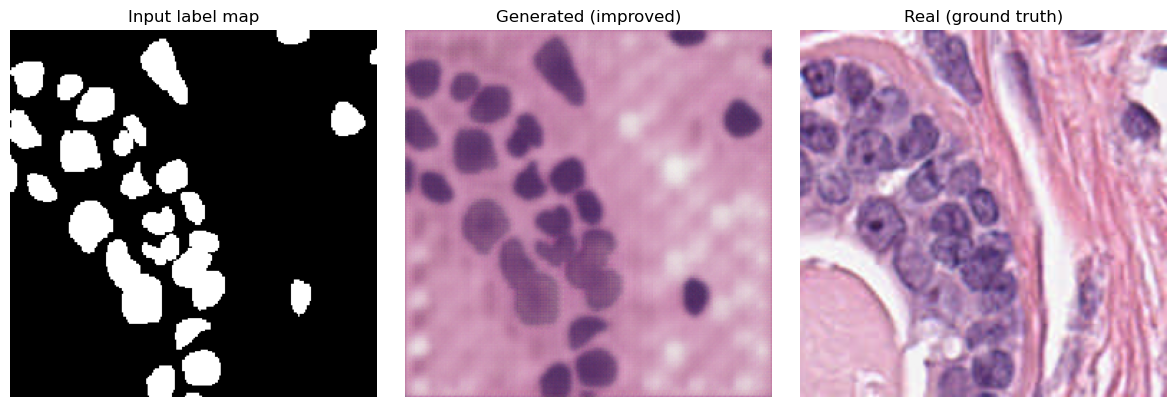

In [4]:
result = run_inference_on_paired_image(
    paired_image_path=INPUT_IMAGE,
    generator=generator,
    device=device,
)

fig = make_side_by_side_figure(result, model_name=MODEL_NAME)
plt.show()

## 5. (Optional) Compare all models on the same image

Side-by-side comparison of all five trained models on the same input. This is the same kind of figure included in the project report.

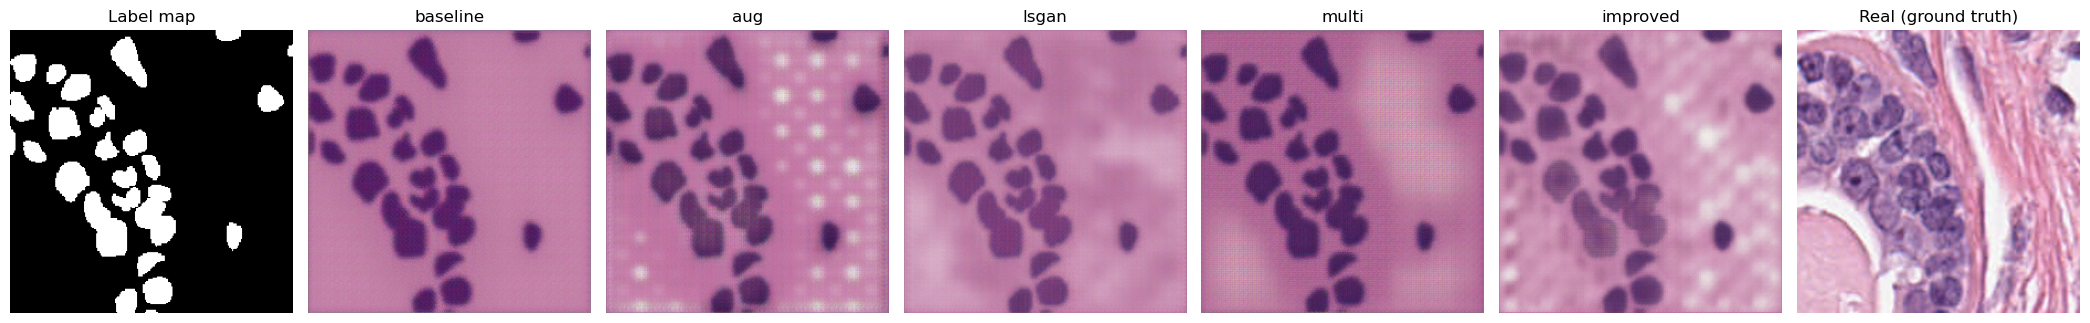

In [5]:
# ------------------------------------------------------------
# Optional: compare all available models on the same image
# ------------------------------------------------------------

USE_LOCAL_CHECKPOINTS = False  # Set to True only for local development

outputs_per_model = {}

for name in AVAILABLE_MODELS:
    if USE_LOCAL_CHECKPOINTS:
        ckpt = resolve_checkpoint_path(
            model_name=name,
            local_checkpoints_dir=CHECKPOINTS_DIR,
        )
    else:
        ckpt = resolve_checkpoint_path(
            model_name=name,
        )

    g, dev = load_generator(ckpt)

    res = run_inference_on_paired_image(
        paired_image_path=INPUT_IMAGE,
        generator=g,
        device=dev,
    )

    outputs_per_model[name] = res
    del g

# Build a grid: label / each model's output / real.
any_result = next(iter(outputs_per_model.values()))
model_names = list(outputs_per_model.keys())
num_cols = 2 + len(model_names)

fig, axes = plt.subplots(1, num_cols, figsize=(3 * num_cols, 4))

axes[0].imshow(any_result["label"])
axes[0].set_title("Label map")
axes[0].axis("off")

for col, name in enumerate(model_names, start=1):
    axes[col].imshow(outputs_per_model[name]["generated"])
    axes[col].set_title(name)
    axes[col].axis("off")

axes[-1].imshow(any_result["real"])
axes[-1].set_title("Real (ground truth)")
axes[-1].axis("off")

plt.tight_layout()
plt.show()